In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: For pretty scientific plots
try:
    import scienceplots
    plt.style.use(["science", "grid", "high-vis", "no-latex"])
except ImportError:
    plt.style.use("default")

Imports and Setup

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/datasets/'))

['__pycache__', 'base_dataset.py', 'readme.txt', 'loveda.py', '__init__.py']


Instantiate the Dataset

In [ ]:
# Set these paths to your actual data locations
root = '/content/drive/MyDrive/AML_Semantic_Segmentation/data/LoveDA/Train/Urban/images_png'
list_path = '/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/data/list/loveda/train.lst'

train_dataset = LoveDA(
    root=root,
    list_path=list_path,
    num_classes=7,
    multi_scale=False,
    flip=False,
    ignore_label=255,
    base_size=1024,
    crop_size=(1024, 1024)
)

print(f"Train Dataset length: {len(train_dataset)}")

# Set these paths to your actual data locations
root = '/content/drive/MyDrive/AML_Semantic_Segmentation/data/LoveDA/Val/Urban/images_png'
list_path = '/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/data/list/loveda/val.lst'

val_dataset = LoveDA(
    root=root,
    list_path=list_path,
    num_classes=7,
    multi_scale=False,
    flip=False,
    ignore_label=255,
    base_size=1024,
    crop_size=(1024, 1024)
)

print(f"Val Dataset length: {len(val_dataset)}")

NameError: name 'LoveDA' is not defined

Visualize a Few Samples and Print Label Ranges

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/tools')  # so you can import datasets
sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/')
from visualization import decode_segmap

# Use your dataset's mean and std (from config or dataset)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

num_samples = 2
all_labels = []

for idx in range(num_samples):
    image, label, edge, size, name = train_dataset[idx]
    # image: torch.Tensor (C, H, W) normalized
    # label: np.ndarray or torch.Tensor (H, W)

    # Unnormalize image for visualization
    if isinstance(image, torch.Tensor):
        img_np = image.numpy().transpose(1,2,0)  # (H, W, C)
    else:
        img_np = image.transpose(1,2,0)
    img_np = (img_np * std + mean)
    img_np = np.clip(img_np, 0, 1)

    # Visualize the label mask with color
    label_vis = decode_segmap(label, ignore_index=-1)  # or whatever your ignore index is

    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title(f"Original Image: {name}")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(label_vis)
    plt.title(f"Label visualization for {name}")
    plt.axis('off')
    plt.show()

    # See unique label values
    print("Unique label values in this mask:", np.unique(label))
    all_labels.append(label)

# Flatten all labels and print global min/max/unique
all_labels_flat = np.concatenate([l.flatten() for l in all_labels])
print(f"\nGlobal label value range in {num_samples} samples: {all_labels_flat.min()} to {all_labels_flat.max()}")
print(f"Unique label values in {num_samples} samples: {np.unique(all_labels_flat)}")


NameError: name 'sys' is not defined

Histogram of Label Distribution

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(all_labels_flat, bins=np.arange(-1,8)-0.5, rwidth=0.8)
plt.title("Label Value Distribution in Sampled Masks")
plt.xlabel("Label Value")
plt.ylabel("Pixel Count")
plt.xticks(np.arange(0, 7))
plt.show()

In [ ]:
import numpy as np
from tqdm import tqdm
from loveda import LoveDA  # adjust import if needed

# Instantiate your dataset (adjust paths/config as needed)
dataset = LoveDA(
    root='data/',  # or your actual root
    list_path='/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/data/list/loveda/val.lst',  # or your actual list
    num_classes=7,
    multi_scale=False,
    flip=False,
    ignore_label=255,
    base_size=720,
    crop_size=(512, 512)
)

all_labels = []

for i in tqdm(range(len(dataset)), desc="Scanning dataset"):
    _, label, _, _, _ = dataset[i]
    all_labels.append(label.flatten())

all_labels = np.concatenate(all_labels)
unique_labels = np.unique(all_labels)

print(f"Unique label values in the dataset: {unique_labels}")
print(f"Label value range: min={unique_labels.min()}, max={unique_labels.max()}")

import collections
counts = collections.Counter(all_labels)
print("Counts per label:", dict(counts))

# RUN

Install Dependencies

In [4]:
!pip install tensorboardX thop albumentations tqdm pyyaml yacs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.3 MB/s eta 0:00:00


Generate dataset list files

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet

!python -m datasets.loveda

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 112, in _get_module_details
  File "/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/datasets/__init__.py", line 9, in <module>
    from .cityscapes import Cityscapes as cityscapes
ModuleNotFoundError: No module named 'datasets.cityscapes'


In [ ]:
import sys

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/')

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/datasets/')

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/tools/')

Train PIDNet-S on Urban LoveDA Validate on Urban LoveDA

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_2b.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_2b
=> creating log/loveda/pidnet_small/pidnet_loveda_2b_2025-08-19-12-10
Namespace(cfg='./configs/loveda/pidnet_loveda_2b.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_urban.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPUT_INDEX: 1
TRAIN:
  A

Evaluate on LoveDA-urban

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/eval.py --cfg configs/loveda/pidnet_loveda_2b.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
=> creating output/loveda/pidnet_loveda_urban
=> creating log/loveda/pidnet_small/pidnet_loveda_urban_2025-08-16-22-15
Namespace(cfg='configs/loveda/pidnet_loveda_urban.yaml', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 6, 'PRINT_FREQ': 10, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'MODEL': CfgNode({'NAME': 'pidnet_small', 'PRETRAINED': './pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar', 'ALIGN_CORNERS': True, 'NUM_OUTPUTS': 2}), 'LOSS': CfgNode({'USE_OHEM': True, 'OHEMTHRES': 0.9, 'OHEMKEEP': 131072, 'CLASS_BALANCE': False, 'BALANCE_WEIGHTS': [0.4, 1.0], 'SB_WEIGHTS': 1.0}), 'DATASET': CfgNode({'ROOT': 'data/', 'DATASET': 'loveda', 'NUM_CLASSES': 7, 'TRAIN_SET': 'list/loveda/train.lst', 'EXTRA_TRAIN_SET': '', 'TEST_SET': 'list/loveda/val.lst'}), 'TRAIN': CfgNode({'IMAGE_SIZE': [1024, 1024], 'BASE_SIZE': 1

Visualize preidctions

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/visualization.py --config configs/loveda/pidnet_loveda_2b.yaml --checkpoint output/loveda/pidnet_loveda_2b/best.pt --split val --output_dir visualizations --num_samples 10

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet


Show some visualizations

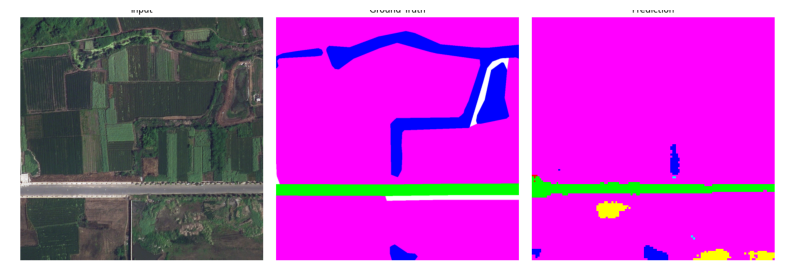

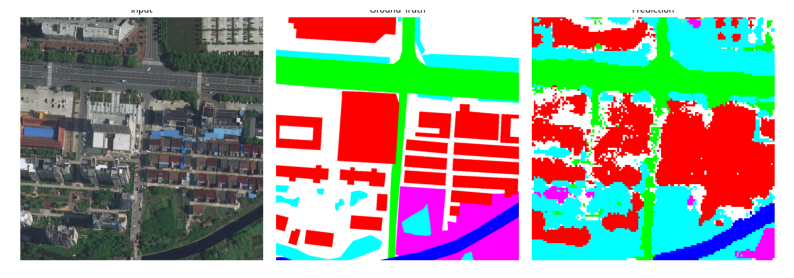

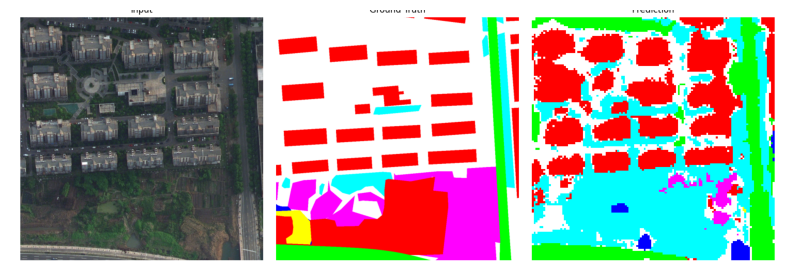

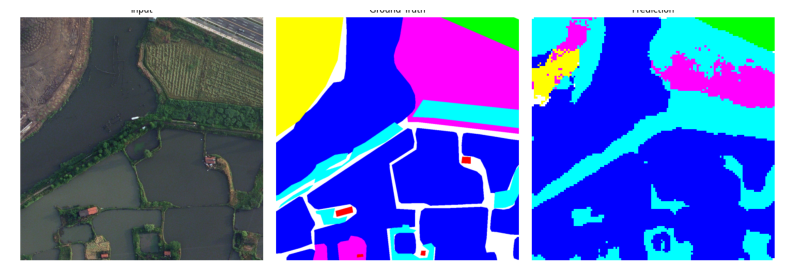

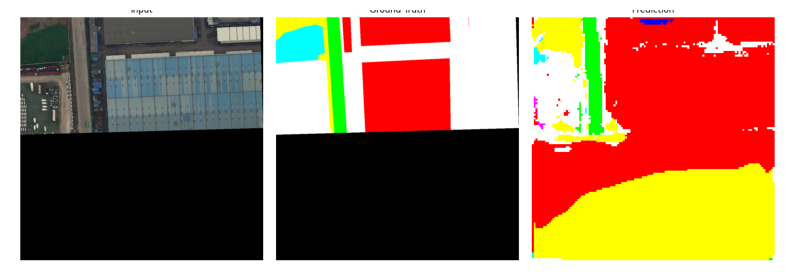

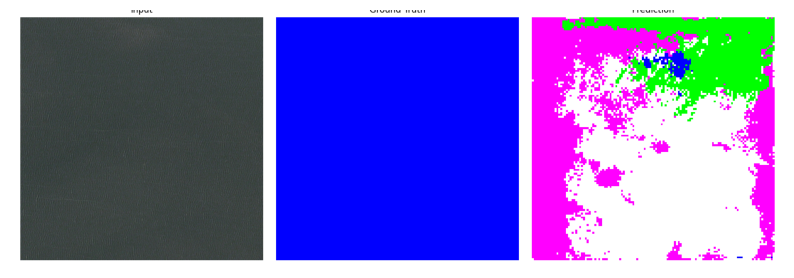

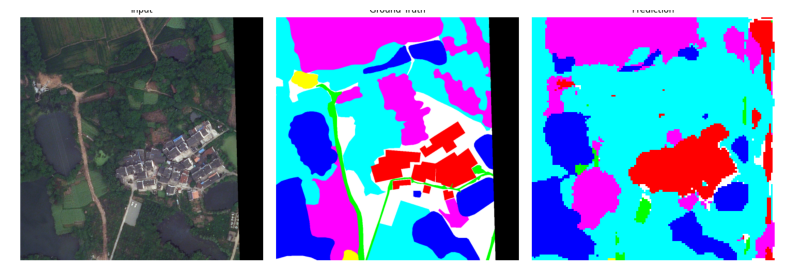

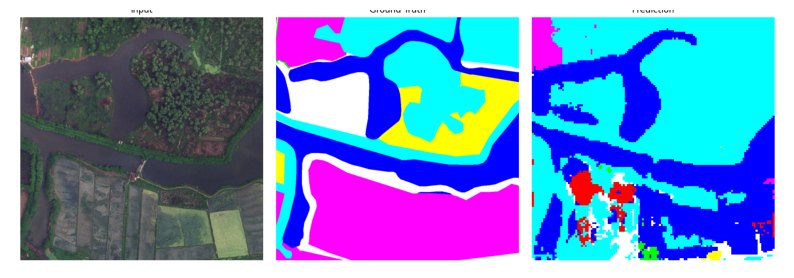

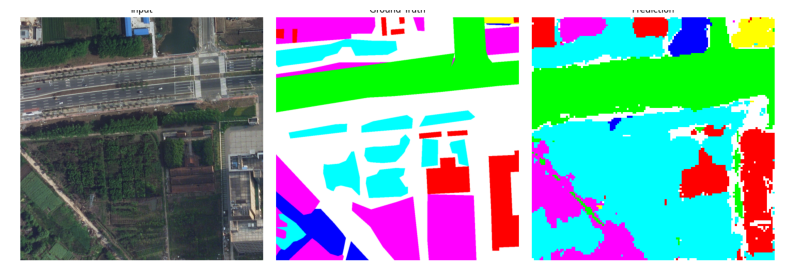

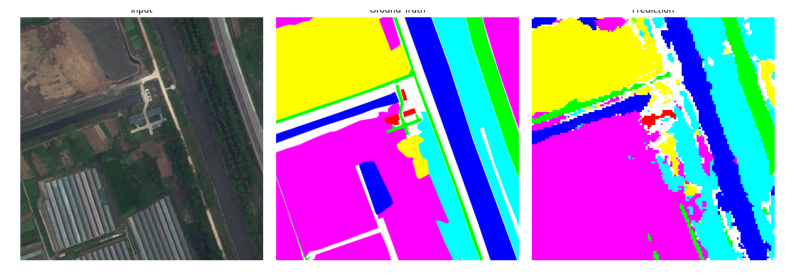

In [ ]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

vis_dir = 'visualizations'
imgs = sorted(glob.glob(f"{vis_dir}/*.png"))
for img_path in imgs[:10]:
    img = Image.open(img_path)
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

Train PIDNet on Urban LoveDA Validate on Rural LoveDA

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3a.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3a
=> creating log/loveda/pidnet_small/pidnet_loveda_3a_2025-08-17-15-46
Namespace(cfg='./configs/loveda/pidnet_loveda_3a.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPUT_INDEX: 1
TRAIN:
  B

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/visualization.py --config configs/loveda/pidnet_loveda_3a.yaml --checkpoint output/loveda/pidnet_loveda_3a/best.pt --split val --output_dir visualizations --num_samples 10

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet


In [ ]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

vis_dir = 'visualizations'
imgs = sorted(glob.glob(f"{vis_dir}/*.png"))
for img_path in imgs[:10]:
    img = Image.open(img_path)
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

aug 1 - flips

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug1.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug1
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug1_2025-08-17-20-14
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug1.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPUT_INDE

aug 2 - blur

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug2.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug2
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug2_2025-08-18-09-12
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug2.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPUT_INDE

aug 3 - multiply

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug3.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug3
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug3_2025-08-17-23-04
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug3.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPUT_INDE

aug 1 2 - flip blur

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug1-2.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug1-2
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug1-2_2025-08-18-09-15
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug1-2.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPU

aug 1 3 - flip multiply

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug1-3.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug1-3
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug1-3_2025-08-18-00-15
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug1-3.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPU

aug 2 3 - blur multiply

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug2-3.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug2-3
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug2-3_2025-08-18-00-47
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug2-3.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPU

aug 1 2 3 - flip blur multiply

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug1-2-3.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug1-2-3
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug1-2-3_2025-08-18-01-58
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug1-2-3.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
 

In [5]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug4.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug4
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug4_2025-08-21-11-03
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug4.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPUT_INDE

In [6]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug1-4.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug1-4
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug1-4_2025-08-21-12-36
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug1-4.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPU

In [7]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug3-4.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug3-4
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug3-4_2025-08-21-13-53
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug3-4.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: False
  OUTPU

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python ./tools/train.py --cfg ./configs/loveda/pidnet_loveda_3b_aug1-3-4-5.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_3b_aug1-3-4-5
=> creating log/loveda/pidnet_small/pidnet_loveda_3b_aug1-3-4-5_2025-08-21-15-30
Namespace(cfg='./configs/loveda/pidnet_loveda_3b_aug1-3-4-5.yaml', seed=304, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024
  BATCH_SIZE_PER_GPU: 6
  FLIP_TEST: False
  IMAGE_SIZE: [1024, 1024]
  MODEL_FILE: 
  MULTI_SCALE: F